In [18]:
import numpy as np
print("Working:", np.__version__)

Working: 2.2.6


# 🚗 Tesla Stock Price Prediction using Deep Learning

## 🎯 Objective
- Predict Tesla stock closing price
- Use LSTM model
- Forecast future prices (1, 5, 10 days)

## 📦 Import Libraries

In this step, we import all necessary libraries required for data analysis, visualization, and deep learning.

- numpy → numerical operations  
- pandas → data handling  
- matplotlib → visualization  
- sklearn → preprocessing & evaluation  
- tensorflow → building deep learning models  

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

## 📂 Load Dataset
Load Tesla stock dataset using pandas.

In [20]:
df = pd.read_csv("TSLA.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## 🔍 Data Understanding
Check structure and statistical summary of dataset.

In [21]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


## 🧹 Data Preprocessing
- Convert Date column  
- Set index  
- Handle missing values  

In [22]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.fillna(method='ffill', inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_8648\2888749607.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## 📈 Data Visualization
Plot closing price to observe trends.

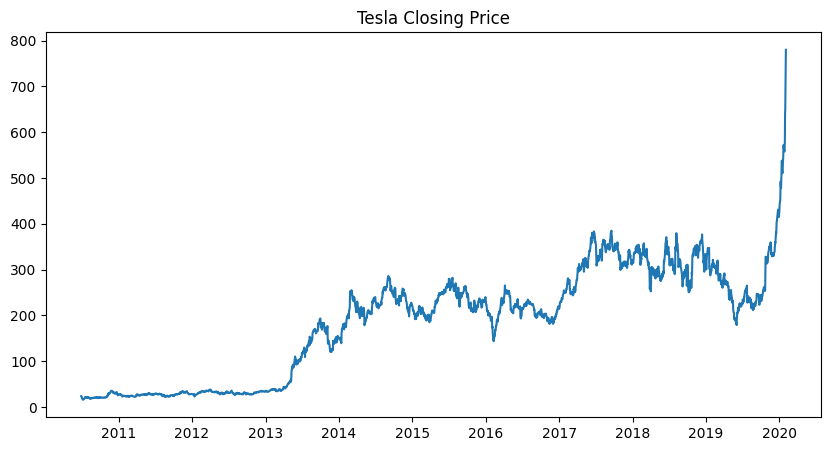

In [23]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Tesla Closing Price")
plt.show()

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [24]:
data = df[['Close']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

## 🔄 Time-Series Sequence Creation
Use last 60 days to predict next value.

In [25]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

## ✂️ Train-Test Split
Split data into training and testing sets.

In [26]:
train_size = int(len(X)*0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

## ⚙️ Model Compilation
- Loss function: MSE  
- Optimizer: Adam  
## 🏋️ Model Training
- Model trained on historical data  
- Dropout used to avoid overfitting  
- Model learns sequential patterns  

In [27]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=10, batch_size=32)

c:\Users\user\OneDrive\Desktop\TeslaProj\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0050
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.6226e-04
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.4738e-04
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.4734e-04
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 6.3526e-04
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.0158e-04
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.9008e-04
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.2628e-04
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.3186e-04
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 4.6806e-04


## 🔮 Model Prediction
Predict values using test data.
- Values converted back to original scale 

In [28]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


## 📉 Actual vs Predicted
Compare actual and predicted prices.
- Used visualization to analyze performance  
- Calculated Mean Squared Error (MSE)  

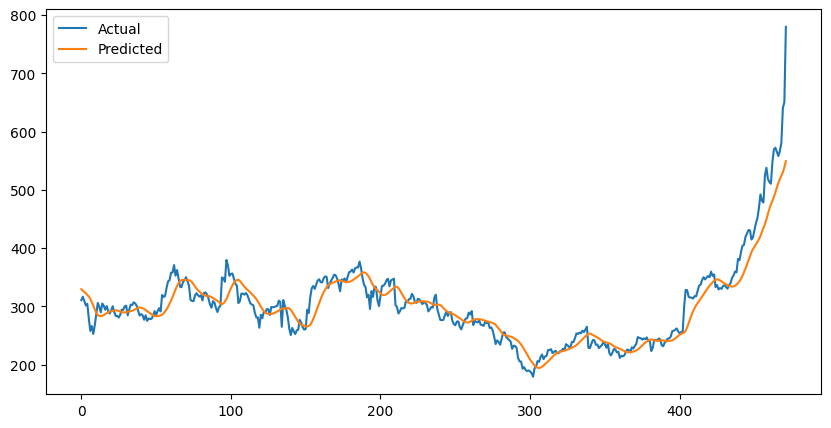

In [29]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

## 💾 Save Model
Save trained model for reuse in Streamlit app.

In [32]:
model.save("lstm_model.h5")
print("Model saved ✅")

Model saved ✅


 ## 🔮 Future Forecast

- Predicted stock prices for next 1, 5, 10 days  
- Recursive prediction method used  

In [ ]:
def predict_future(model, data, days=5):
    temp_input = list(data[-60:])
    output = []

    for i in range(days):
        x_input = np.array(temp_input[-60:]).reshape(1,60,1)
        pred = model.predict(x_input)
        temp_input.append(pred[0])
        output.append(pred[0])

    return scaler.inverse_transform(output)

print("Next 5 days:", predict_future(model, scaled_data, 5))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Next 5 days: [[567.11580669]
 [576.81970534]
 [581.72041581]
 [583.43778254]
 [583.0663689 ]]


## ⚠️ Limitations

- Market is highly volatile  
- External factors not considered  
- Multi-day prediction errors increase  

## 🚀 Future Improvements

- Add sentiment analysis  
- Use GRU / Transformer models  
- Include macroeconomic data  

## 📅 Project Timeline

- Data Processing → 2 days  
- Model Building → 2 days  
- Deployment → 1 day  
- Documentation → 1 day  

## 📌 Conclusion

- LSTM model performs well for time-series prediction  
- Captures trends effectively  
- Stock prediction is challenging due to volatility  

### Future Improvements:
- Add sentiment analysis  
- Use advanced models like GRU  